In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.legend_handler import HandlerTuple
import subprocess
import os

matplotlib.rcParams.update({"axes.grid": True, "font.size": 15})
# matplotlib.rcParams.keys()

In [3]:
def readmetadata(fname):
    on = False
    lines = ""
    with open(fname) as file:
        for line in file:
            idx = line.find("Hamiltonian")
            if idx != -1:
                on = True
            if on and line.find("--") == -1 and line.find("[") == -1:
                lines += line
            idx = line.find("Called")
            if idx != -1:
                on = False
                break
    meta_dict = {"Description": lines}
    return meta_dict

def valErr_format(val, err):
    if err > 0:
        place = int(np.floor(np.log10(err)))
        
        # Handle the edge case where rounding bumps it to the next power of 10 (e.g., 0.98 -> 1.0)
        if round(err, -place) >= 10**(place + 1):
            place += 1    
        decimals = max(0, -place)
        err_rounded = round(err, -place)
        val_rounded = round(val, -place)
    else:
        decimals = 3  # Fallback if error is exactly 0
        err_rounded = 0.0
        val_rounded = val

    return f"{val_rounded:.{decimals}f} ± {err_rounded:.{decimals}f}"

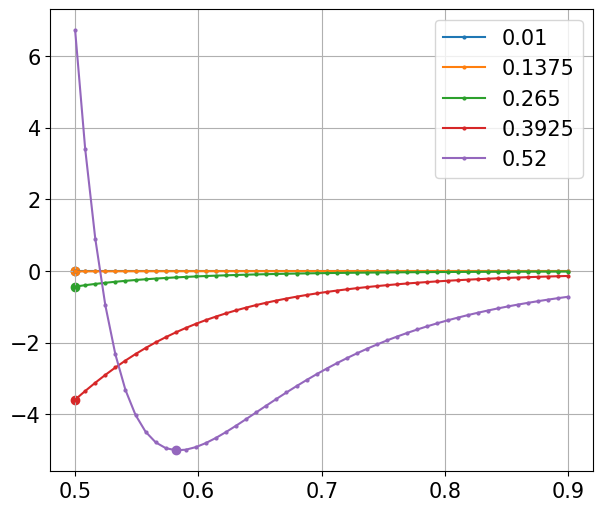

In [4]:
fig = plt.figure(figsize=(7,6))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 5
omega = 1
r = np.linspace(0.5, stop=0.9)
sigma = np.linspace(start=0.01, stop=0.52, num=5)
for i in range(sigma.size):
    var = (sigma[i] / r)**6
    V = 4 * enEps * var * (var - 1)
    rmin = np.argmin(V)
    ax.errorbar(r, V, marker='.', markersize=4, label=sigma[i])
    ax.scatter(r[rmin], V[rmin])
ax.legend()

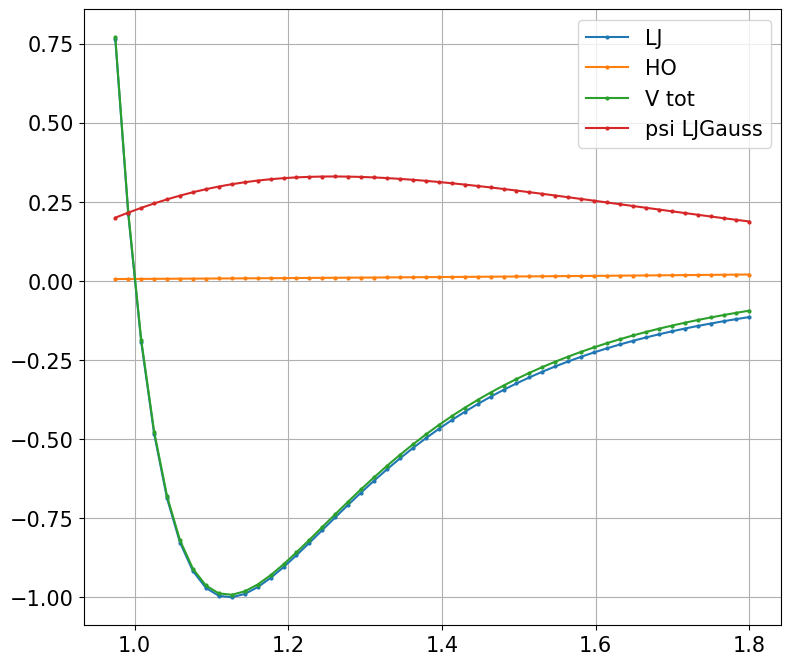

In [5]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

enEps = 1
omega = 1
r = np.linspace(0.975, stop=1.8)
sigma = 1
var = (sigma / r)**6
LJ = 4 * enEps * var * (var - 1)
omega = 0.111803
HO = 0.5 * omega**2 * r**2
V = LJ + HO
alpha = 2
LJGauss = np.exp(-1/(2 * alpha) * r**2 - 0.5 * (sigma/r)**5)
# rmin = np.argmin(V)
ax.errorbar(r, LJ, marker='.', markersize=4, label="LJ")
ax.errorbar(r, HO, marker='.', markersize=4, label="HO")
ax.errorbar(r, V, marker='.', markersize=4, label="V tot")
ax.errorbar(r, LJGauss**2, marker='.', markersize=4, label="psi LJGauss")
# ax.scatter(r[rmin], V[rmin])
ax.legend()

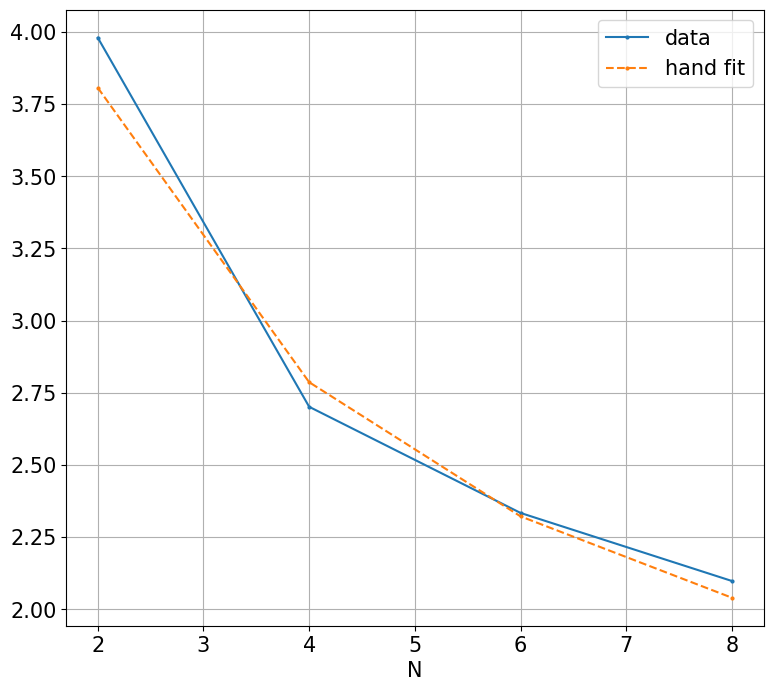

In [13]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2,4,6,8])
alpha = np.array([3.98009743, 2.70142433, 2.33365906, 2.09789077])
ax.errorbar(N, alpha, marker='.', markersize=4, label="data")
ax.errorbar(N, 5.2/N**(0.45), marker='.', markersize=4, ls='--', label="hand fit")
ax.set_xlabel("N")
ax.legend()

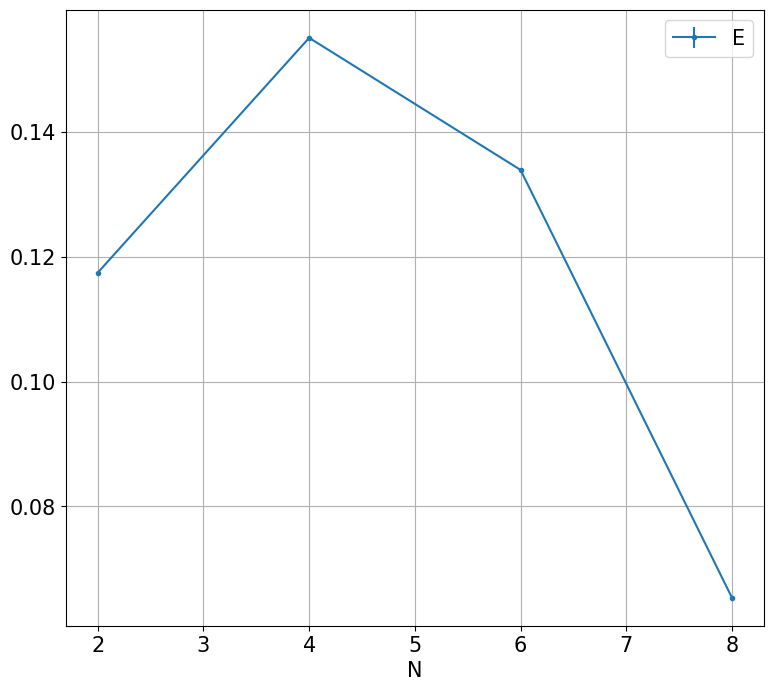

In [15]:
fig = plt.figure(figsize=(9,8))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0])

N = np.array([2,4,6,8])

E = np.array([1.174467088e-01, 1.550433449e-01, 1.338948238e-1, 6.541837939e-02])
dE = np.array([1.112297955e-05, 1.870194814e-05, 8.325633413e-5, 3.063435401e-05])

ax.errorbar(N, E, dE, marker='.', markersize=6, label="E")
ax.set_xlabel("N")
ax.legend()